In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 8.9
https://www.l3harrisgeospatial.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
def get_obs_data(box, vege_mask_flag):
    
    #cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_All_ensMean.nc')
    cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
    
    #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        da = da.where(vege_mask>0)
        
    da = da.sel(time=slice("1959","2014"))
    da = da.where(~cam5.isnull())
    
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [4]:
def get_noise(era5_da,scen,ens_mean,box,vege_mask_flag):
    runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
            'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)],
            'Ant':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}

    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        #mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_'+scen+'_run'+number+'.nc')
        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice("1959","2014"))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [5]:
def get_mean_and_noise(scen, box, vege_mask_flag):
    
    #era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')

    #ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/95percentile/FWI_95p_'+scen+'_ensMean.nc')
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice("1959","2014"))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(era5_da,scen,ens_mean,box,vege_mask_flag)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()

    del ens_mean
    
    return((ens_mean_array, np.array(noise)))


In [6]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

vege_mask = full_lai_max.where(full_lai_max>3.5)


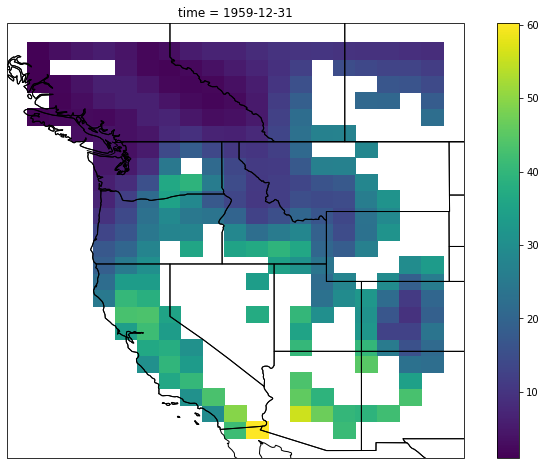

getting ALL mean and noise
getting NAT mean and noise
getting Ant mean and noise
getting obs
got obs
got arrays
running gendetec


In [7]:
'''
OF at one truncation for FINGER_TRUNC output
'''

boxes = [[(32,55),(232,256)]]#,'full',[(32,55),(232,250)],[(32,55),(235,245)]]

for vege_mask_flag in [True]:
    for box in boxes:
        #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/cam5_resolution/ERA5_FWI_95p_cam5_resolution.nc')
        da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        if box != 'full':
            da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        if vege_mask_flag:
            da = da.where(vege_mask>0)
        da = da.sel(time=slice("1959","2014"))
        
        fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

        da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
        axs.coastlines()  # cartopy function
        axs.add_feature(cf.BORDERS)
        axs.add_feature(cf.STATES)

        plt.show()
        plt.close(fig)


        IDL.retall

        print('getting ALL mean and noise')
        all_ens_mean,noise_all = get_mean_and_noise('All', box, vege_mask_flag)
        print('getting NAT mean and noise')
        nat_ens_mean,noise_nat = get_mean_and_noise('Nat', box, vege_mask_flag)
        print('getting Ant mean and noise')
        ant_ens_mean,noise_ant = get_mean_and_noise('Ant', box, vege_mask_flag)
        print('getting obs')
        data_obs = get_obs_data(box, vege_mask_flag)
        print('got obs')
        data_scen = np.array([ant_ens_mean,nat_ens_mean])

        data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))

        print('got arrays')

        trunc = 30

        IDL.data_obs = data_obs
        IDL.data_scen = data_scen
        IDL.data_noise_1 = data_noise_1
        IDL.data_noise_2 = data_noise_2
        IDL.trunc = trunc
        IDL.finger_trans = 1
        IDL.z_best = 1

        print('running gendetec')
        #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
        #        data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, finger_trans=finger_trans")
        IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
                data_noise_2=data_noise_2, trunc=trunc, finger_trans=finger_trans, z_best=z_best")

        finger_trans = IDL.finger_trans
        z_best = IDL.z_best
        beta_est = IDL.BETA_EST

        best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        da.close()
    

In [31]:
z_best_ant_finger = np.array(z_best[0])
z_best_nat_finger = np.array(z_best[1])

z_best_obs = np.array(z_best[2])


print(z_best_ant_finger)
print('')
print(z_best_nat_finger)
print('\n\n\n')
print('')
print(z_best_obs)
print('')

print(best_ant*z_best_ant_finger+best_nat*z_best_nat_finger)
print('')


[1.00689366 2.35776932 2.24727236 ... 2.11500404 2.02570621 1.77695   ]

[2.97217388 5.81021896 7.49001307 ... 3.31480274 3.67888123 3.19392061]





[ 5.43912428 11.44670631 13.10041753 ...  8.13956123  8.36140347
  7.29738194]

[ 5.43912432 11.44670635 13.10041768 ...  8.13956116  8.36140343
  7.29738191]



In [20]:
'''
create dataset with d4pdf All, Nat, Ant signals and Nat and Ant fingerprints from finger_trans
'''

era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
box = [(32,55),(232,256)]

Ant_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc')
Ant_da = Ant_da.rename({'FWI':'Ant'})
Nat_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')
Nat_da = Nat_da.rename({'FWI':'Nat'})

cam5_ds = xr.merge([Ant_da,Nat_da])

cam5_ds = cam5_ds.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
cam5_ds = cam5_ds.where(vege_mask>0)
cam5_ds = cam5_ds.sel(time=slice("1959","2014"))
cam5_ds = cam5_ds.where(~era5_da.isnull())

cam5_pixel = cam5_ds.stack(pixel=("latitude", "longitude"))
cam5_no_nan = cam5_pixel.dropna("pixel", how="all")

# add fingerprints
ant_finger_trans = np.array([val[1] for val in finger_trans])
nat_finger_trans = np.array([val[0] for val in finger_trans])

z_best_ant_finger = np.array(z_best[0])
z_best_nat_finger = np.array(z_best[1])

z_best_obs = np.array(z_best[2])

cam5_add_fingers = cam5_no_nan.assign(ant_finger_trans=(['time','lev','pixel'],ant_finger_trans.reshape(56,1,256)),
                                      nat_finger_trans=(['time','lev','pixel'],nat_finger_trans.reshape(56,1,256)),
                                      ant_finger_from_zbest=(['time','lev','pixel'],z_best_ant_finger.reshape(56,1,256)),
                                      nat_finger_from_zbest=(['time','lev','pixel'],z_best_nat_finger.reshape(56,1,256)),
                                      est_obs_from_zbest=(['time','lev','pixel'],z_best_obs.reshape(56,1,256)))

cam5_unstack = cam5_add_fingers.unstack("pixel")

cam5_final = cam5_unstack.assign(nat_finger_from_trans = 1/(cam5_unstack['nat_finger_trans']+1),
                                 ant_finger_from_trans = 1/(cam5_unstack['ant_finger_trans']+1))



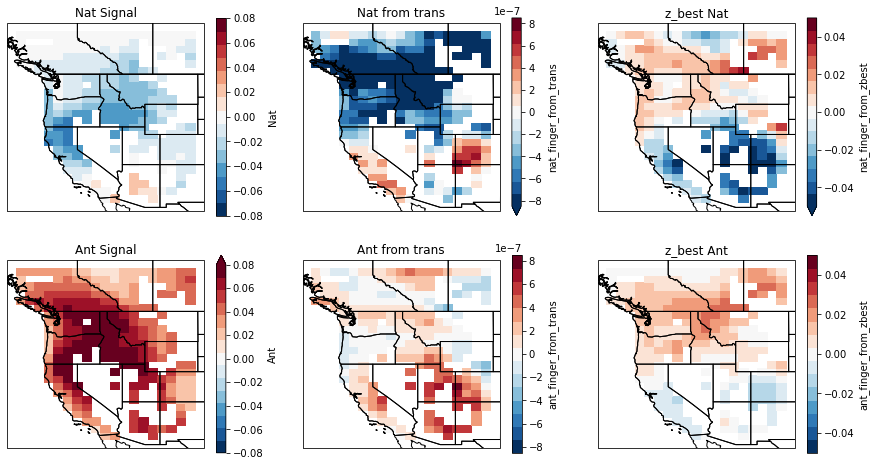

In [21]:
'''
plot Nat + Ant signals versus fingerprints
'''

fig,axs = plt.subplots(2,3,figsize=(15,8),sharex=True,sharey=True,subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

titles = ['Nat Signal','Nat from trans','z_best Nat','Ant Signal','Ant from trans','z_best Ant']
for i,var in enumerate(['Nat','nat_finger_from_trans','nat_finger_from_zbest','Ant','ant_finger_from_trans','ant_finger_from_zbest']):
    
    if i in [0,3]:
        rnge = [-0.08,0.08] 
    elif i in [1,4]:
        rnge = [-.85e-6,.85e-6]
    elif i in [2,5]:
        rnge = [-0.05,0.05] 
    
    cmap = cm.get_cmap('RdBu_r', 15)
    
    xr.apply_ufunc(get_linregress_slope, cam5_final[var], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_title(titles[i])


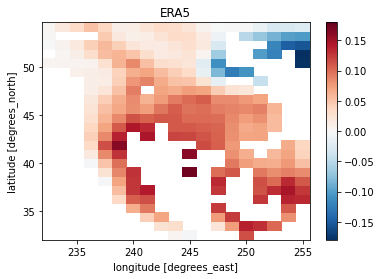

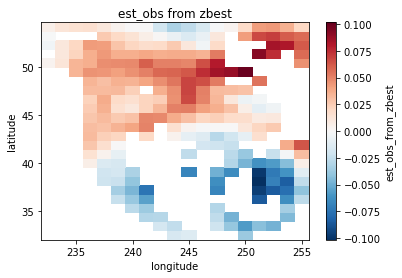

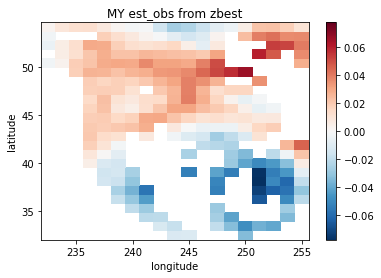

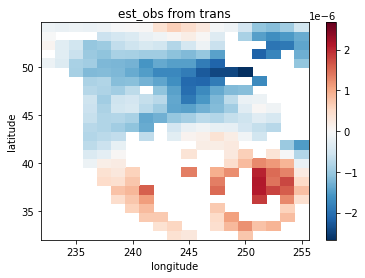

In [25]:
box = [(32,55),(232,256)]
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
da = da.where(vege_mask>0)
da = da.sel(time=slice("1959","2014"))

my_zbest_est_obs = cam5_final['ant_finger_from_zbest'] + cam5_final['nat_finger_from_zbest']

est_obs_trans = best_ant * cam5_final['ant_finger_from_trans'] + best_nat * cam5_final['nat_finger_from_trans']

xr.apply_ufunc(get_linregress_slope, da, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('ERA5')
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, cam5_final['est_obs_from_zbest'], input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('est_obs from zbest')
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, my_zbest_est_obs, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('MY est_obs from zbest')
plt.show()
plt.close(fig)

xr.apply_ufunc(get_linregress_slope, est_obs_trans, input_core_dims=[["time"]], vectorize = True).plot()#ax=axs[i],transform=ccrs.PlateCarree(),vmin=rnge[0],vmax=rnge[1],cmap=cmap)
plt.title('est_obs from trans')
plt.show()
plt.close(fig)



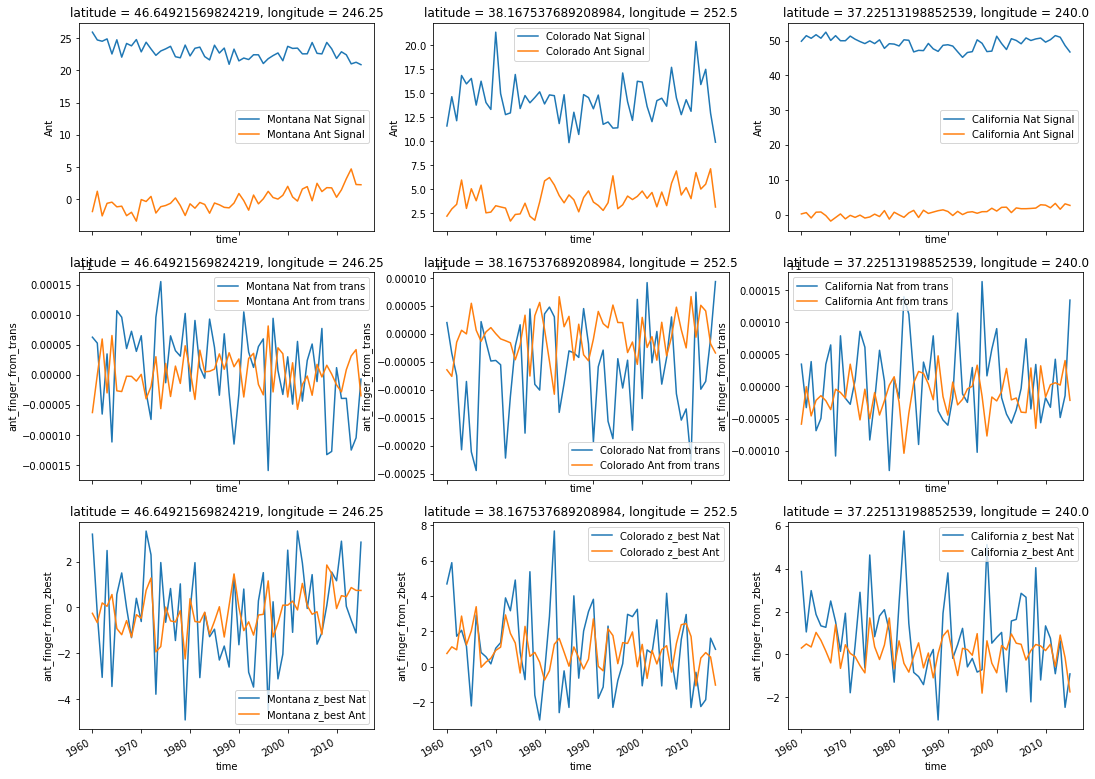

In [28]:
western_Montana = [47,246]
Colorado = [38,252]
central_California = [37,240]

fig,axs = plt.subplots(3,3,figsize=(18,12),sharex=True)
titles = ['Nat Signal','Ant Signal','Nat from trans','Ant from trans','z_best Nat','z_best Ant']
labels = ['Montana','Colorado','California']
for i,var in enumerate(['Nat','Ant','nat_finger_from_trans','ant_finger_from_trans','nat_finger_from_zbest','ant_finger_from_zbest']):
    
    da = cam5_final[var]
    
    montana_cell = da.sel(latitude=western_Montana[0],longitude=western_Montana[1],method='nearest')
    colorado_cell = da.sel(latitude=Colorado[0],longitude=Colorado[1],method='nearest')
    california_cell = da.sel(latitude=central_California[0],longitude=central_California[1],method='nearest')

    for j,cell in enumerate([montana_cell,colorado_cell,california_cell]):
        if i < 2:
            row = 0 
        elif i < 4:
            row = 1
        else:
            row = 2
            
        cell.plot(ax=axs[row][j],label=labels[j] + ' ' + titles[i])
        axs[row][j].legend()
